In [291]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [292]:
REGION = 'Nord'
YEAR = 2024

In [293]:
grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [294]:
grouped_file.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,15.31,40.87,0.0003,0.0080,0.0080,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,16.48,39.99,0.0224,0.6956,0.6956,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,16.54,39.62,0.0379,1.1753,1.1753,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,15.32,38.63,0.0021,0.0636,0.0636,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,17.54,39.52,0.0104,0.3233,0.3233,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648


In [295]:
grouped_file.shape

(1740, 75)

In [296]:
grouped_file_previous.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,2023,1,2022,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.203670,-0.104947,-0.332973,0.104947,0.200802,-0.110086,-0.332716,0.110086,0.008989,0.016678,0.015613,0.016678,27.31,36.32,18.29,15.33,43.85,0.0088,0.2720,0.2720,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,2023-01,2023,1,2022,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.198848,-0.131351,-0.303877,0.131351,0.192091,-0.138810,-0.297378,0.138810,0.012856,0.014102,0.014963,0.014102,27.29,35.32,19.27,15.81,43.15,0.0072,0.2226,0.2226,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,2023-01,2023,1,2022,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.200869,-0.111810,-0.314533,0.111810,0.200773,-0.110383,-0.315749,0.110383,0.010803,0.011977,0.008706,0.011977,26.94,34.50,19.38,16.44,42.65,0.0065,0.2013,0.2013,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,2023-01,2023,1,2022,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.201936,-0.079751,-0.295551,0.079751,0.207849,-0.081288,-0.297314,0.081288,0.013906,0.026026,0.019961,0.026026,26.46,35.17,17.75,15.64,41.99,0.0197,0.6118,0.6118,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,3,5,8,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,2023-01,2023,1,2022,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.191215,-0.042046,-0.283002,0.042046,0.188943,-0.039992,-0.284222,0.039992,0.021207,0.019909,0.044741,0.019909,27.43,34.46,20.40,17.91,42.08,0.0074,0.2300,0.2300,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [297]:
grouped_file_previous.shape

(1740, 75)

In [298]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [299]:
grouped_file

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,15.31,40.87,0.0003,0.0080,0.0080,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,16.48,39.99,0.0224,0.6956,0.6956,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,16.54,39.62,0.0379,1.1753,1.1753,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,15.32,38.63,0.0021,0.0636,0.0636,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,17.54,39.52,0.0104,0.3233,0.3233,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1

In [300]:
weather_acc = grouped_file[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()
weather_acc_previous = grouped_file_previous[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc']].copy()

weather_df = pd.concat([weather_acc_previous, weather_acc], ignore_index=True)
weather_df.rename(columns={'dt_placement': 'dt_weather_acc'}, inplace=True)

In [301]:
weather_df

,dt_weather_acc,GID0,GID1,GID2,GID3,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2023-01,nord,benoue,bibemi,adoumri,15.33,43.85,0.2720
1,2023-01,nord,benoue,bibemi,bibemi,15.81,43.15,0.2226
2,2023-01,nord,benoue,bibemi,bide,16.44,42.65,0.2013
3,2023-01,nord,benoue,bibemi,dengui,15.64,41.99,0.6118
4,2023-01,nord,benoue,bibemi,djaloumi,17.91,42.08,0.2300
...,...,...,...,...,...,...,...,...
3475,2024-12,nord,mayo-rey,touboro,mbeing,16.17,29.88,0.2660
3476,2024-12,nord,mayo-rey,touboro,ngai-lara,16.70,32.07,0.0024
3477,2024-12,nord,mayo-rey,touboro,touboro,15.68,32.12,0.0185
3478,2024-12,nord,mayo-rey,touboro,vogzom,15.45,31.43,0.0551


In [302]:
biovars_temp = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_temp.rename(columns={'year': 'year_biovars'}, inplace=True)

In [303]:
biovars_df = (
    biovars_temp
    .groupby(['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'])
    .mean(numeric_only=True)
    .reset_index()
    .round(2)
)

In [304]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023,nord,benoue,bibemi,adoumri,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0
1,2023,nord,benoue,bibemi,bibemi,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0
2,2023,nord,benoue,bibemi,bide,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0
3,2023,nord,benoue,bibemi,dengui,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0
4,2023,nord,benoue,bibemi,djaloumi,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0


In [305]:
biovars_df.shape

(145, 24)

In [306]:
df_current = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col] + ['monthly_lst_min', 'monthly_lst_max', 'monthly_rainfall_acc', 'rainfall_acc']).copy()

In [307]:
df_current.shape

(1740, 52)

In [308]:
df_current['year_biovars'] = df_current['year']-1
df_current['dt_weather_acc'] = df_current['dt_placement']-1

In [309]:
df_current.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,0.0003,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2023,2023-12
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,0.0224,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2023,2023-12
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,0.0379,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2023,2023-12
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,0.0021,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,2023,2023-12
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,0.0104,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2023,2023-12


In [310]:
df_current.shape

(1740, 54)

In [311]:
dataset = pd.merge(df_current, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [312]:
dataset.shape

(1740, 73)

In [313]:
dataset = pd.merge(dataset, weather_df, on=['dt_weather_acc', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [314]:
dataset.shape

(1740, 76)

In [315]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,0.0003,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2023,2023-12,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0,16.35,41.31,4.1380
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,0.0224,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2023,2023-12,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0,16.89,39.18,1.3028
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,0.0379,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2023,2023-12,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0,16.77,39.12,0.0000
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,0.0021,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,2023,2023-12,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0,15.82,39.88,1.7327
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,0.0104,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2023,2023-12,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0,18.20,39.30,0.0000


In [316]:
dataset.rename(columns={'monthly_lst_min': 'lst_min_prev_month', 'monthly_lst_max': 'lst_max_prev_month', 'monthly_rainfall_acc': 'rainfall_acc_prev_month'}, inplace=True)

<Axes: >

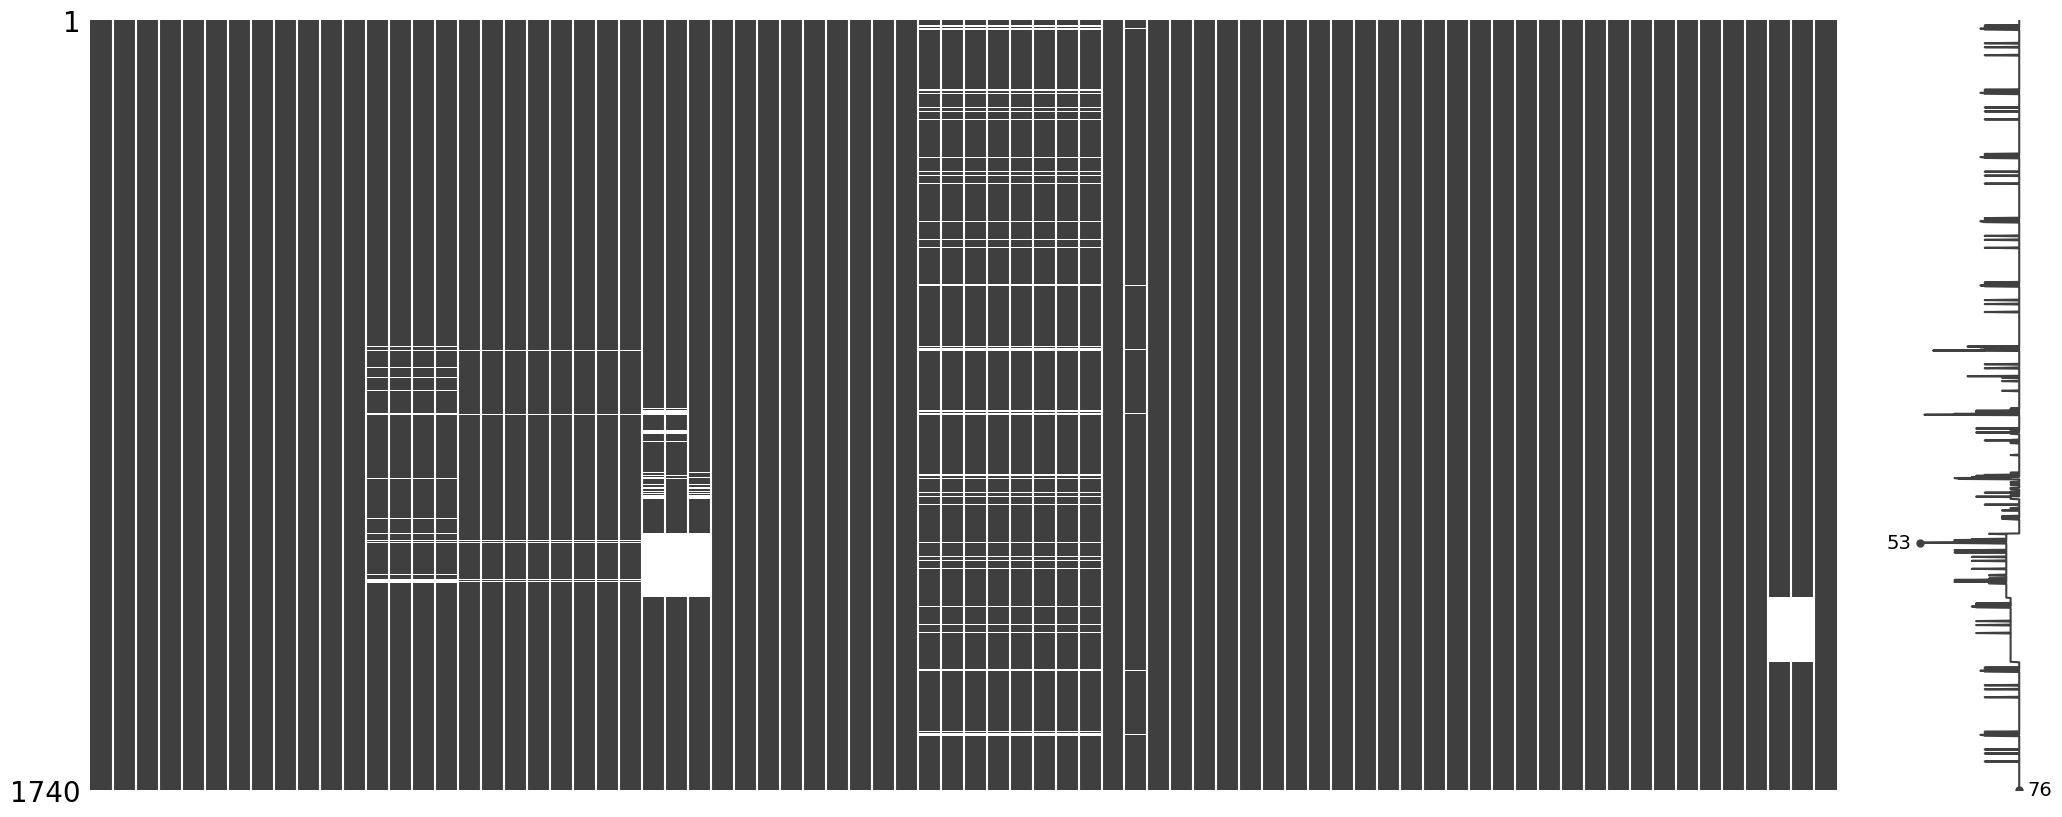

In [317]:
msno.matrix(dataset)

In [318]:
dataset

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.210098,-0.147509,-0.335927,0.147509,0.211859,-0.151186,-0.347978,0.151186,0.013583,0.021531,0.013390,0.021531,27.31,36.91,17.71,0.0003,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2023,2023-12,29.58,20.67,55.86,349.57,52.0,15.0,37.0,26.17,29.33,34.50,26.17,2048.0,510.0,0.0,107.96,1270.0,4.0,306.0,1270.0,16.35,41.31,4.1380
1,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.229805,-0.148718,-0.346496,0.148718,0.227733,-0.150692,-0.346205,0.150692,0.015927,0.016900,0.014961,0.016900,27.25,35.94,18.56,0.0224,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2023,2023-12,29.17,18.83,53.81,326.37,50.0,15.0,35.0,25.83,29.00,33.67,25.67,1975.0,470.0,0.0,104.36,1188.0,1.0,315.0,1028.0,16.89,39.18,1.3028
2,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.229615,-0.121265,-0.347762,0.121265,0.230149,-0.117264,-0.348967,0.117264,0.015778,0.016250,0.012650,0.016250,26.93,35.46,18.39,0.0379,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2023,2023-12,29.50,19.33,55.24,311.89,51.0,16.0,35.0,27.00,28.67,34.00,26.33,1843.0,450.0,0.0,106.75,1165.0,0.0,285.0,960.0,16.77,39.12,0.0000
3,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.232036,-0.131119,-0.310579,0.131119,0.236233,-0.132011,-0.317560,0.132011,0.021837,0.026530,0.017731,0.026530,26.42,35.12,17.72,0.0021,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,3,5,8,2023,2023-12,29.33,18.83,57.07,296.44,48.0,15.0,33.0,26.83,27.83,33.83,26.83,2093.0,475.0,0.0,104.82,1267.0,1.0,325.0,1267.0,15.82,39.88,1.7327
4,2024-01,2024,1,2023,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215183,-0.053718,-0.312861,0.053718,0.223605,-0.039268,-0.316439,0.039268,0.036640,0.030206,0.037070,0.030206,27.31,34.84,19.77,0.0104,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2023,2023-12,29.88,19.08,59.64,263.82,49.0,17.0,32.0,27.50,29.17,33.83,27.17,1826.0,447.0,0.0,110.29,1191.0,0.0,254.0,963.0,18.20,39.30,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2024-12,2024,12,2023,0.0,1.000,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,0.404566,0.004045,-0.360921,-0.004045,0.407666,0.007945,-0.362101,-0.007945,0.026467,0.029746,0.018991,0.029746,22.13,27.18,17.10,0.0086,125988.49,1351.46,5.49,165.60,710.63,180.16,0.0,416.45,9674.69,975.21,6.24,51.83,161.28,6.21,0.0,3164.67,22,20.0,20,9,9,4,4,4,2023,2024-11,25.75,15.00,50.00,291.94,44.0,14.0,30.0,23.33,25.17,29.67,23.33,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,15.99,29.07,0.0257
1736,2024-12,2024,12,2023,0.0,1.000

In [319]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc)